# Project : Bank Marketing & deposit prediction modeling
- 프로젝트 목적 : 은행 데이터를 바탕으로 최적 마케팅 파악 & deposit 이진분류 예측 모델 개발
- 데이터 정보
    - 규모 : 11200 rows * 17 columns
    - 기간 : ???
    - 출처 : [(Kaggle) Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data)
- 최종 수정 : 2026-03-20

## 라이브러리 import

In [1]:
# 데이터 처리
import numpy as np
import pandas as pd
from tqdm import tqdm

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
## 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 모델링 (분류)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

## 데이터 로드 & 탐색

In [2]:
# 데이터 불러오기
PATH = "C:\\Users\\user\\Desktop\\work\\project\\bank-marketing-analysis\\data\\raw\\"

df = pd.read_csv(f"{PATH}bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


칼럼 정리
- campaign : 이번 접촉(연락) 횟수
- pdays : 마지막 연락으로 부터 지난 일수
- previous : 현재 캠페인 이전 접촉(연락) 횟수
- poutcome : 이전 마케팅 성공여부

확인 필요
- month, day : 마지막 연락 월일
- duration : contact 했을 시 통화시간

In [3]:
# 데이터 확인
print("============= info =============")
print(df.info(), "\n")
print("============= describe =============")
print(df.describe(), "\n")
print("============= null sum =============")
print(df.isnull().sum())
print("total Null:", df.isnull().sum().sum(), "\n")

============= info =============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None 

============= describe =============
                age   

In [4]:
# 범주형 변수의 고유값과 빈도 확인
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"============= {col} value_counts =============")
    print(df[col].value_counts(), "\n")

============= job value_counts =============
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64 

============= marital value_counts =============
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64 

============= education value_counts =============
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64 

============= default value_counts =============
default
no     10994
yes      168
Name: count, dtype: int64 

============= housing value_counts =============
housing
no     5881
yes    5281
Name: count, dtype: int64 

============= loan value_counts =============
loan
no     9702
yes    1460
Name: count, dtype: int64 

============= contact value_counts ====

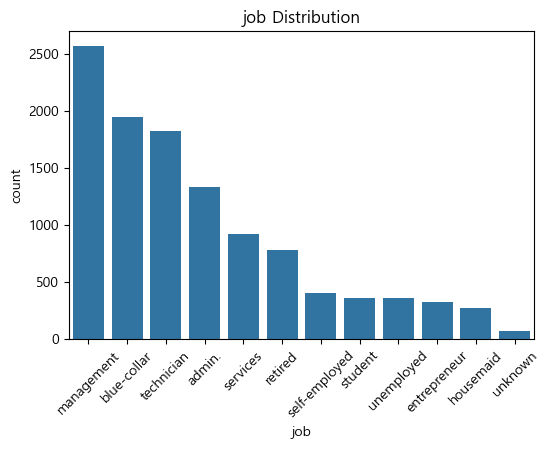

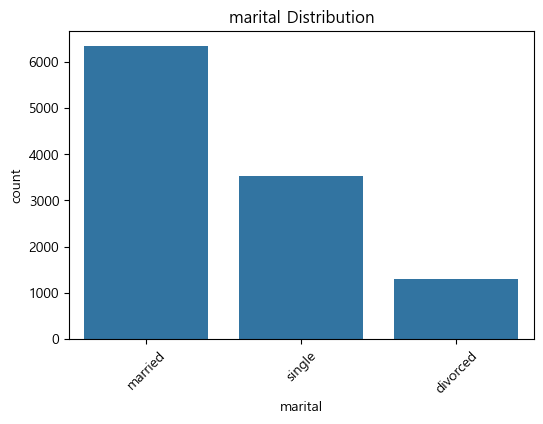

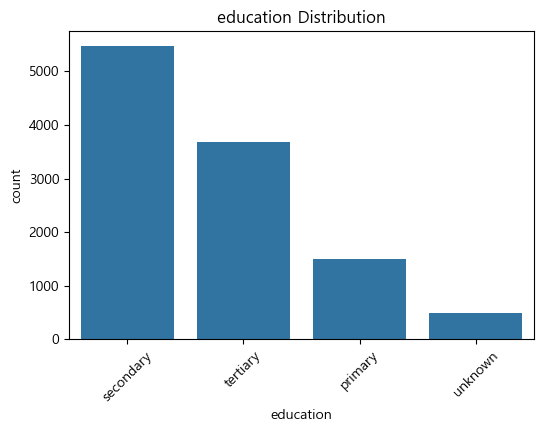

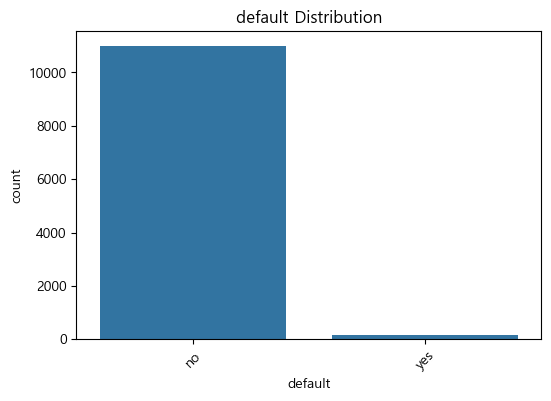

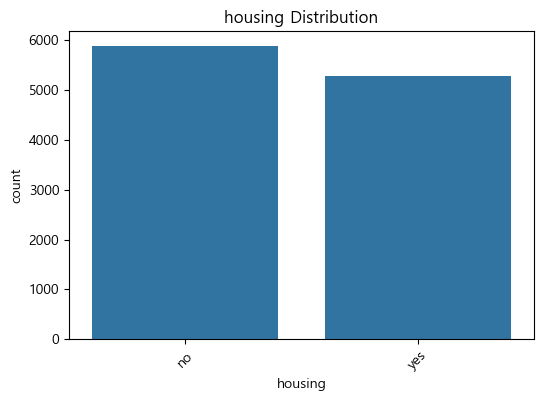

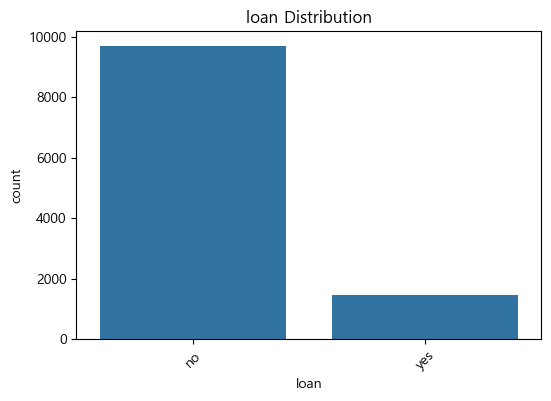

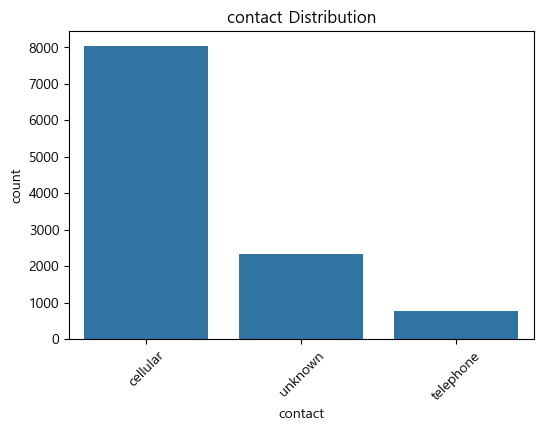

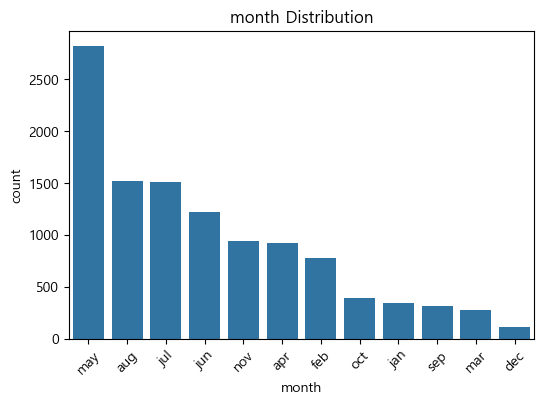

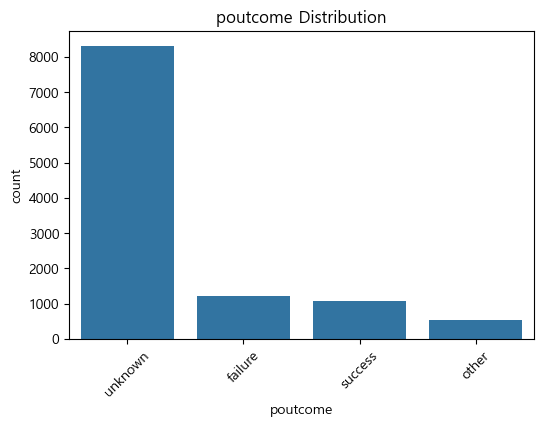

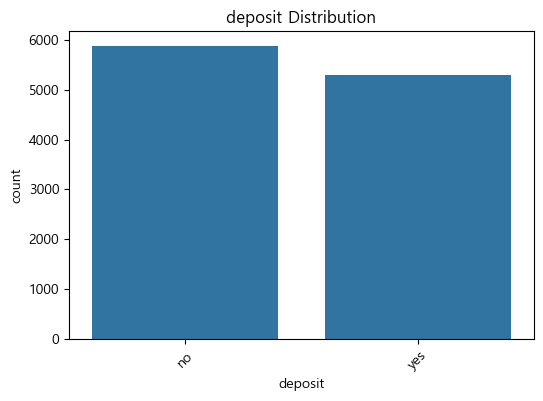

In [5]:
# 범주형 변수의 분포 확인
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [6]:
# 숫자형 변수의 고유값과 빈도 확인
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    print(f"============= {col} distribution =============")
    print(df[col].describe(), "\n")

============= age distribution =============
count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64 

============= balance distribution =============
count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64 

============= day distribution =============
count    11162.000000
mean        15.658036
std          8.420740
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         31.000000
Name: day, dtype: float64 

============= duration distribution =============
count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dty

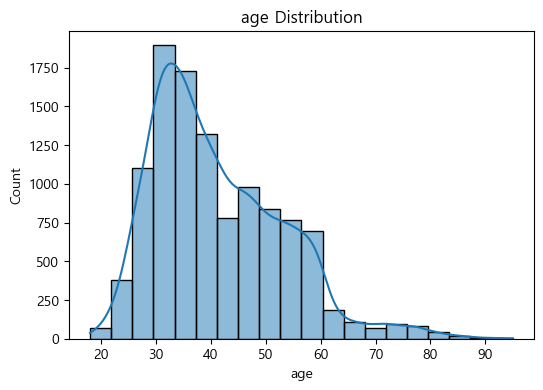

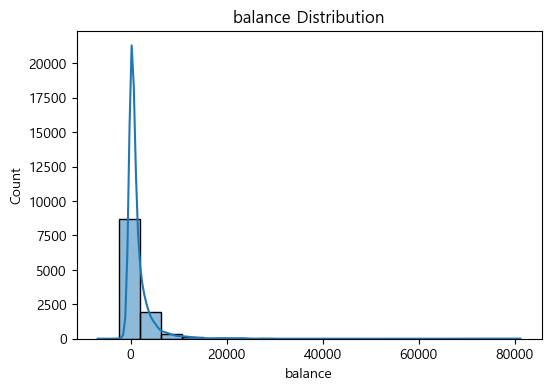

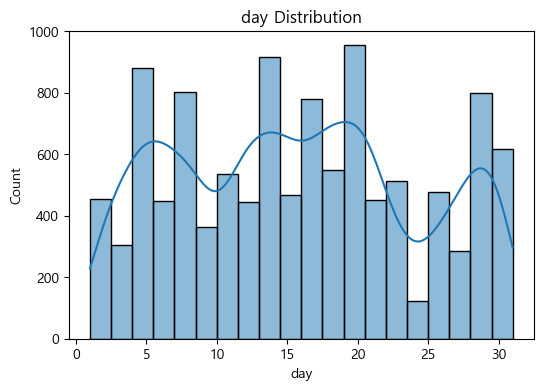

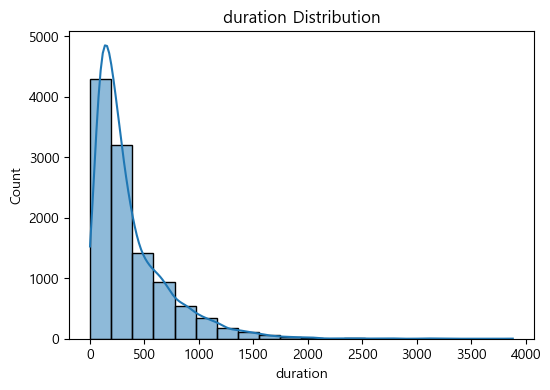

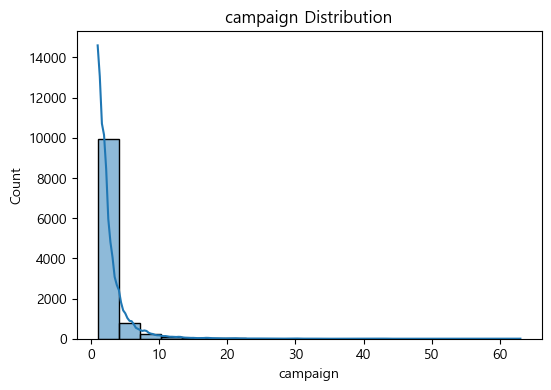

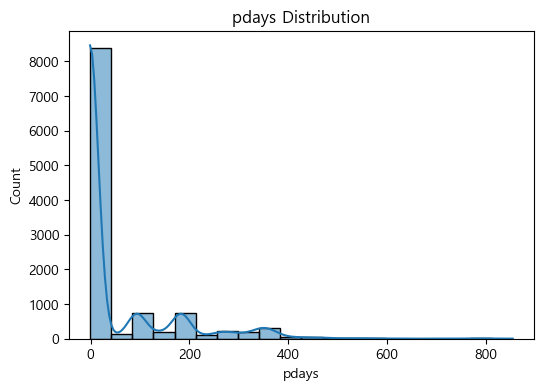

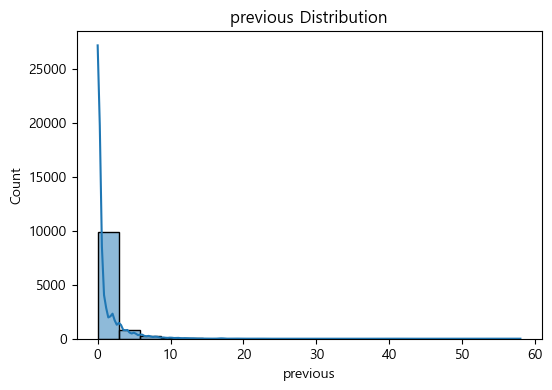

In [7]:
# 숫자형 변수의 분포 확인
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"{col} Distribution")
    plt.show()

In [8]:
# 숫자형 변수의 이상치 확인 (IQR 기준)
def check_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    outlier_mask = (df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr)
    return outlier_mask.sum()

for col in numeric_cols:
    outliers = check_outliers_iqr(df, col)
    print(f"{col} column IQR 기준 이상치: {outliers}건")

age column IQR 기준 이상치: 171건
balance column IQR 기준 이상치: 1055건
day column IQR 기준 이상치: 0건
duration column IQR 기준 이상치: 636건
campaign column IQR 기준 이상치: 601건
pdays column IQR 기준 이상치: 2750건
previous column IQR 기준 이상치: 1258건


In [9]:
# 중복 데이터 확인
df.duplicated().sum()

0

**실행 결과 및 해석**
- 데이터 결측치(isnull 기준) 및 중복 없음. but 값이 unknown 인 칼럼 존재
- cols type : numeric 7, object 10(deposit 포함)
- job, education, contact, poutcome 4개 column unknown 값
    - job : 비중 매우 낮음(0.6%) 기타 혹은 응답 사항 이외로 봐야할 듯 -> unknown 그대로 사용
    - edu : 비중 낮음(5% 이하) 처리 필요, 나이대별 평균? 중앙값? 등 다른 cols 바탕으로 재분배?
    - contact : 비중 높음(20%) 
    - poutcome : 비중 매우 높음(80%)
- deposit yes/no 비율 1:1 에 가까움

## Feature Engineering

In [10]:
# age 그룹 칼럼 생성
age_groups = [0, 25, 35, 45, 55, 65, 75, 85, 100]
# age_groups = [0, 30, 50, 70, 100]
age_labels = ['~24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-84', '85~']
df['age_group'] = pd.cut(df['age'], bins=age_groups, labels=age_labels, right=False)

# age_group 칼럼의 고유값과 빈도 확인
print("============= age_group value_counts =============")
print(df['age_group'].value_counts(sort=False), "\n")

============= age_group value_counts =============
age_group
~24       282
25-34    3628
35-44    3366
45-54    2205
55-64    1256
65-74     254
75-84     147
85~        24
Name: count, dtype: int64 



In [11]:
# month 칼럼과 day 칼럼 합치기
df['month_test'] = pd.to_datetime(df['month'], format='%b').dt.month
df['day_test'] = df['day'].astype(int)
df['date'] = pd.to_datetime(df['month_test']*100 + df['day_test'], format='%m%d')

df.drop(columns=['month_test', 'day_test'], inplace=True)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,date
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,55-64,1900-05-05
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,55-64,1900-05-05
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,35-44,1900-05-05
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,55-64,1900-05-05
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,45-54,1900-05-05


### Feature Engineering 정리

## 전처리

In [13]:
# df.dropna(subset=['column_name'] ,inplace=True)
# df.replace({'column_name': {'old_value': 'new_value'}}, inplace=True)

### job
최빈값?, 아니면 others 로 replace?

In [12]:
# 전처리 전 job 칼럼의 고유값과 빈도
print("============= job value_counts (before) =============")
print(df['job'].value_counts(), "\n")

============= job value_counts (before) =============
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64 



In [13]:
# job 의 unkown 값을 other로 대체
df['job'] = df['job'].replace('unknown', 'other')

# 전처리 결과 확인
print("============= job value_counts (after) =============")
print(df['job'].value_counts(), "\n")

============= job value_counts (after) =============
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
other              70
Name: count, dtype: int64 



### education
age 그룹별 최빈값?

In [14]:
print("============= education value_counts (before) =============")
print(df['education'].value_counts())

============= education value_counts (before) =============
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64


In [15]:
# education 의 unkown 값을 age_group별 최빈값으로 대체
for group in df['age_group'].unique():
    mode_education = df[df['age_group'] == group]['education'].mode()[0]
    df.loc[(df['age_group'] == group) & (df['education'] == 'unknown'), 'education'] = mode_education

# education 전처리 결과 확인
print("============= education value_counts (after) =============")
print(df['education'].value_counts(), "\n")

print("전처리 결과")
print("기존 unkoown 497개 -> secondary 469개, primary 28개로 대체")

============= education value_counts (after) =============
education
secondary    5947
tertiary     3689
primary      1526
Name: count, dtype: int64 

전처리 결과
기존 unkoown 497개 -> secondary 469개, primary 28개로 대체


### contact
컨택트와 다른 칼럼별 상관계수 확인 -> 가장 높은 칼럼을 기준으로 결측치 처리


**포기함**

In [16]:
print("============= contact value_counts (before) =============")
print(df['contact'].value_counts())

============= contact value_counts (before) =============
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64


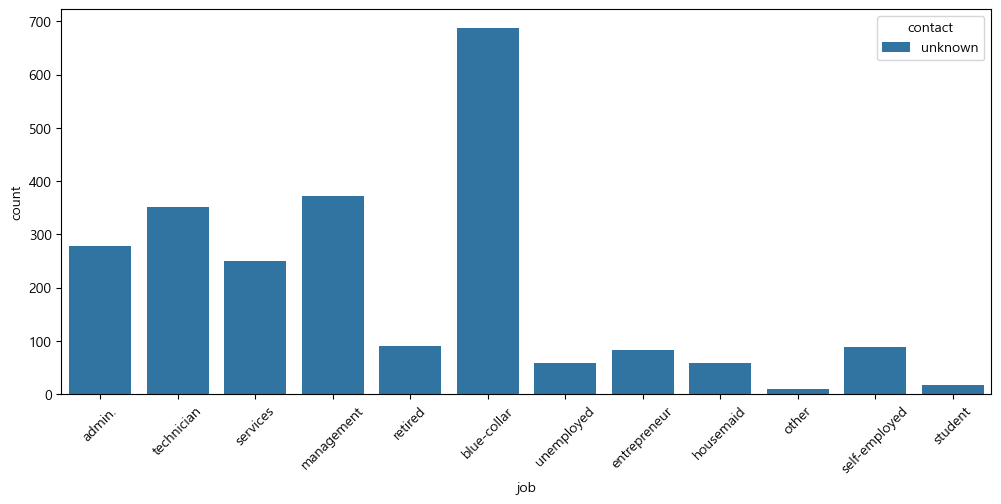

In [17]:
not_null_df = df[df['contact'] == 'unknown']

# 직업별 연락 수단 비중 시각화
plt.figure(figsize=(12, 5))
sns.countplot(data=not_null_df, x='job', hue='contact')
plt.xticks(rotation=45)
plt.show()

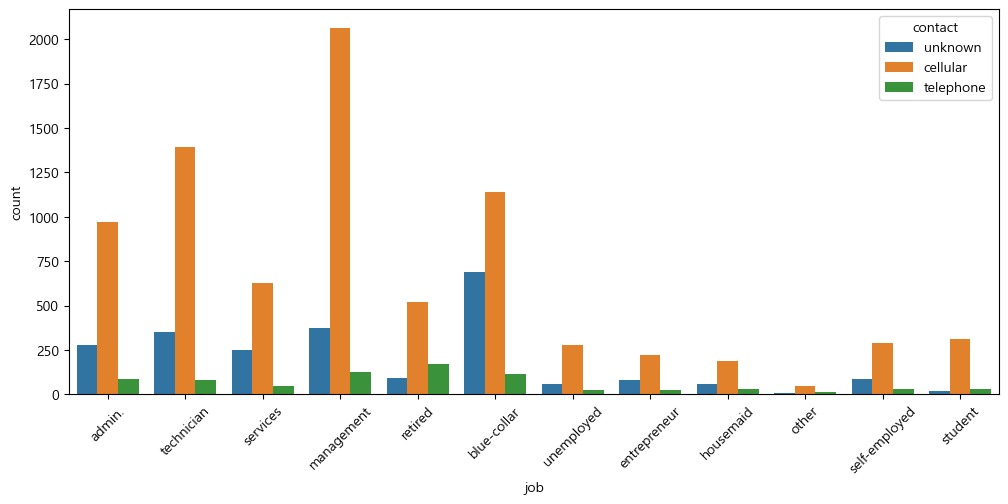

In [18]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='contact')
plt.xticks(rotation=45)
plt.show()

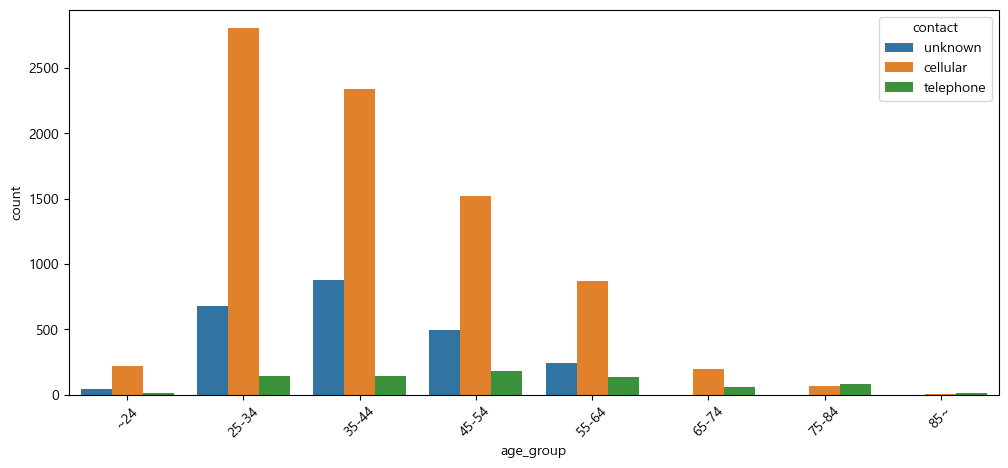

In [19]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='age_group', hue='contact')
plt.xticks(rotation=45)
plt.show()

In [20]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ 두 범주형 변수 사이의 크래머 V 지수를 계산합니다. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # 편향 보정(Bias correction)이 포함된 공식
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 예시: 'job'과 'contact' 사이의 연관성 확인 (결측치 제외 데이터로)
temp_df = df.drop(columns=['contact', *numeric_cols])
for col in temp_df.columns:
    score = cramers_v(temp_df[col], df['contact'])
    print(f"{col}과 Contact의 연관성 점수: {score:.4f}")

job과 Contact의 연관성 점수: 0.1809
marital과 Contact의 연관성 점수: 0.0593
education과 Contact의 연관성 점수: 0.1266
default과 Contact의 연관성 점수: 0.0438
housing과 Contact의 연관성 점수: 0.2601
loan과 Contact의 연관성 점수: 0.0183
month과 Contact의 연관성 점수: 0.4595
poutcome과 Contact의 연관성 점수: 0.2070
deposit과 Contact의 연관성 점수: 0.2566
age_group과 Contact의 연관성 점수: 0.2085
date과 Contact의 연관성 점수: 0.5708


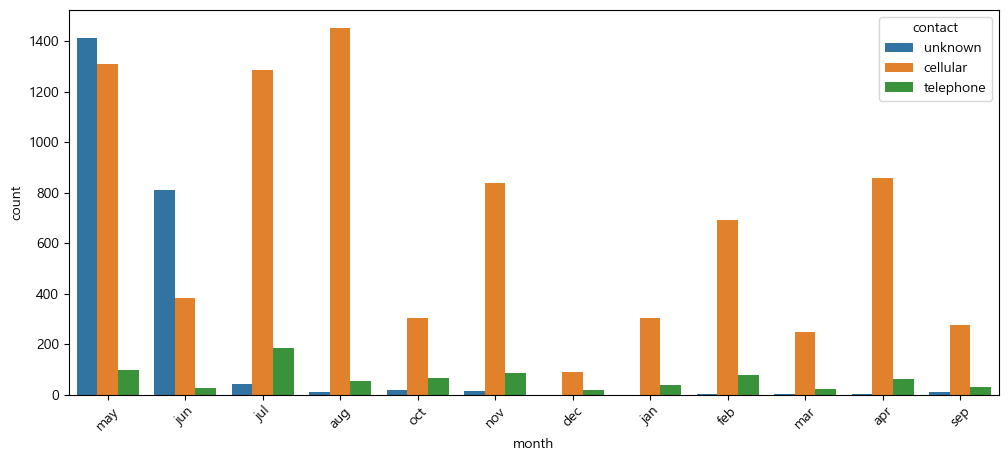

In [21]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='month', hue='contact')
plt.xticks(rotation=45)
plt.show()

### poutcome
이전 마케팅 성공여부인데 값이 성공, 실패, 기타, 알수없음 4개?

In [22]:
print("============= poutcome value_counts (before) =============")
print(df['poutcome'].value_counts())

============= poutcome value_counts (before) =============
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


In [23]:
temp_df = df.drop(columns=['poutcome', *numeric_cols])
for col in temp_df.columns:
    score = cramers_v(temp_df[col], df['poutcome'])
    print(f"{col}과 Poutcome의 연관성 점수: {score:.4f}")

job과 Poutcome의 연관성 점수: 0.0822
marital과 Poutcome의 연관성 점수: 0.0341
education과 Poutcome의 연관성 점수: 0.0537
default과 Poutcome의 연관성 점수: 0.0525
housing과 Poutcome의 연관성 점수: 0.1537
loan과 Poutcome의 연관성 점수: 0.0831
contact과 Poutcome의 연관성 점수: 0.2070
month과 Poutcome의 연관성 점수: 0.1849
deposit과 Poutcome의 연관성 점수: 0.2996
age_group과 Poutcome의 연관성 점수: 0.0736
date과 Poutcome의 연관성 점수: 0.3075


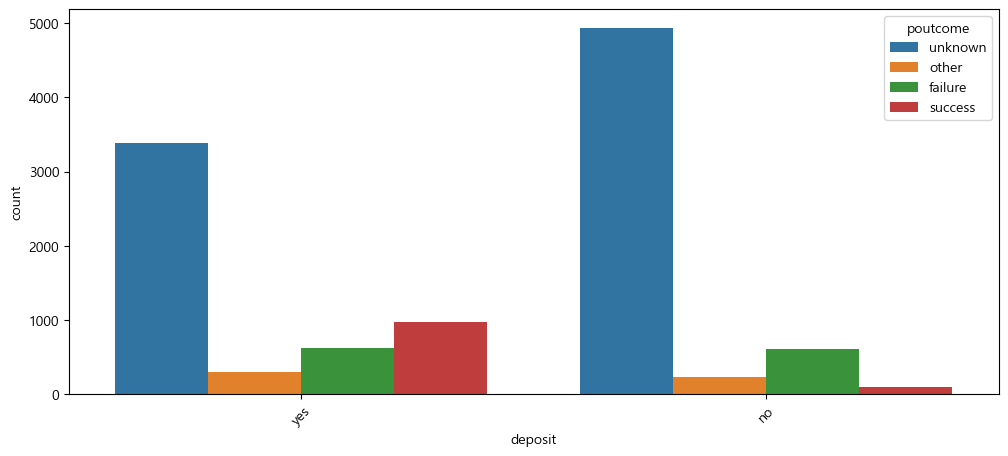

In [24]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='deposit', hue='poutcome')
plt.xticks(rotation=45)
plt.show()

### pdays
-1 (이전 연락 없음) 값 처리여부

In [25]:
df['pdays'].value_counts().sort_index()

pdays
-1      8324
 1         8
 2         8
 4         1
 5         2
        ... 
 805       1
 826       1
 828       1
 842       1
 854       1
Name: count, Length: 472, dtype: int64

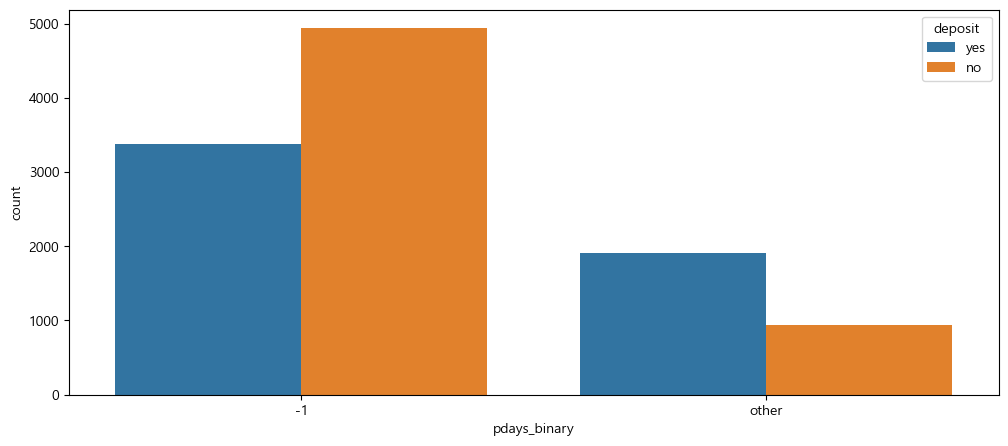

In [26]:
# -1 과 그 외의 값으로 구분하여 시각화
df['pdays_binary'] = df['pdays'].apply(lambda x: '-1' if x == -1 else 'other')
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pdays_binary', hue='deposit')
plt.show()

In [ ]:
# # pdays 그룹핑
# def pdays_grouping(x):
#     if x == -1:
#         return 0
#     elif 0 <= x <= 30:
#         return 1
#     elif 31 <= x <= 90:
#         return 2
#     elif 91 <= x <= 365:
#         return 3
#     else:
#         return 4

# df['pdays_group'] = df['pdays'].apply(pdays_grouping)
# print(df['pdays_group'].value_counts().sort_index())

pdays_group
0    8324
1      56
2     273
3    2257
4     252
Name: count, dtype: int64


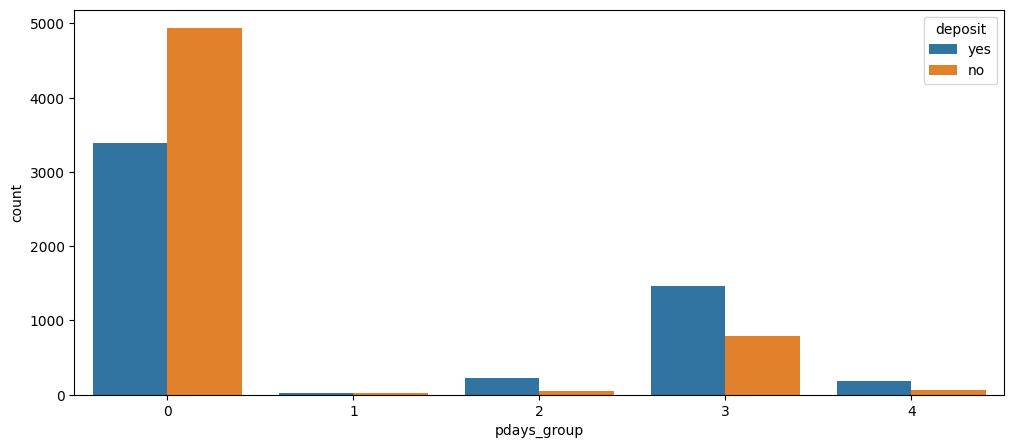

In [ ]:
# plt.figure(figsize=(12, 5))
# sns.countplot(data=df, x='pdays_group', hue='deposit')
# plt.show()

In [27]:
# pdays 그룹핑
def pdays_grouping(x):
    if x == -1:
        return "Never Contacted"
    elif 0 <= x <= 90:
        return "0-90 days"
    elif 91 <= x <= 180:
        return "91-180 days"
    elif 181 <= x <= 270:
        return "181-270 days"
    elif 271 <= x <= 365:
        return "271-365 days"
    else:
        return "More than 365 days"

df['pdays_group'] = df['pdays'].apply(pdays_grouping)
print(df['pdays_group'].value_counts().sort_index())

pdays_group
0-90 days              329
181-270 days           780
271-365 days           527
91-180 days            950
More than 365 days     252
Never Contacted       8324
Name: count, dtype: int64


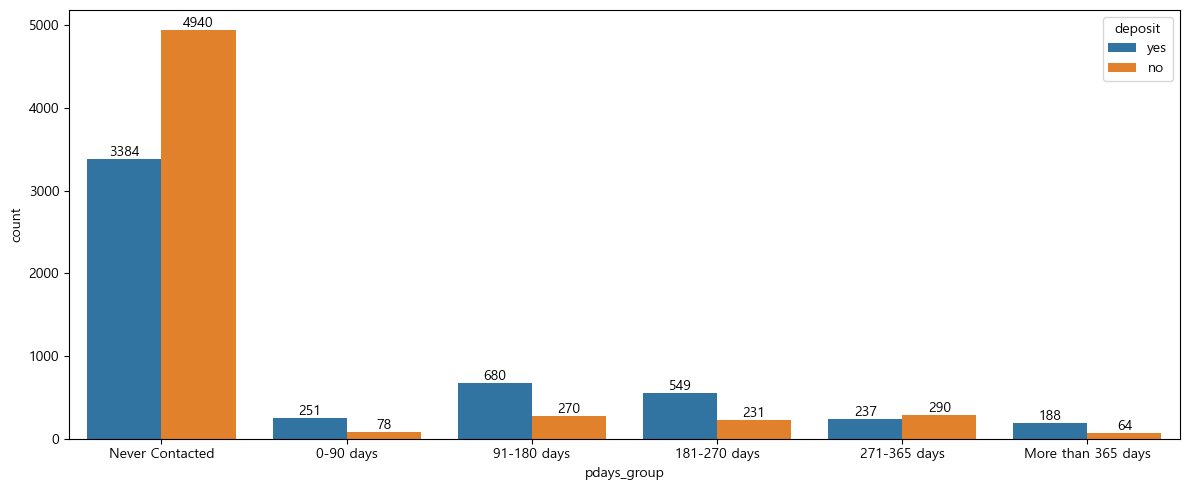

In [28]:
# pdays_group의 label 순서 지정
pdays_group_order = ["Never Contacted", "0-90 days", "91-180 days", "181-270 days", "271-365 days", "More than 365 days"]
df['pdays_group'] = pd.Categorical(df['pdays_group'], categories=pdays_group_order, ordered=True)

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pdays_group', hue='deposit')
# 막대그래프에 값 표시
for container in plt.gca().containers:
    plt.bar_label(container)
plt.tight_layout()
plt.show()

**pdays 전처리**
- pdays 구간별 그룹핑해서 범주형 파생변수 생성

### balance
- balance 값 음수 약 700행

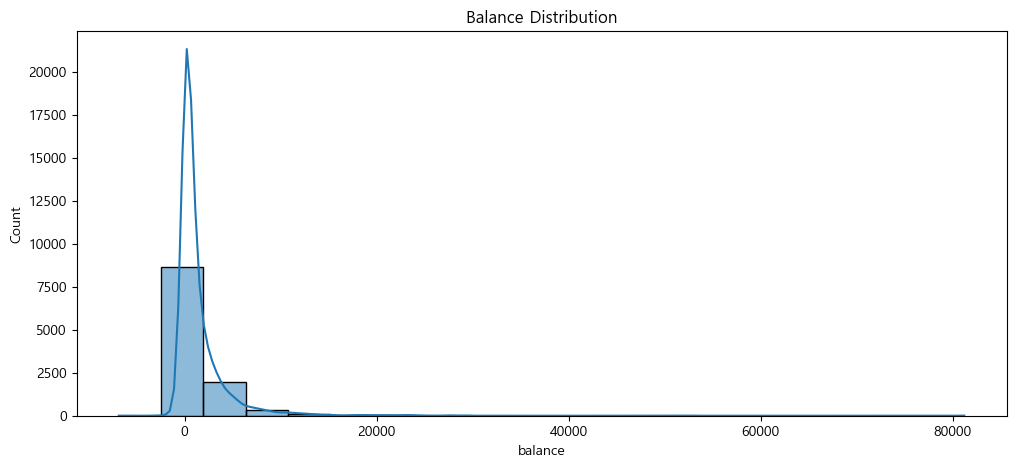

In [29]:
# balance 칼럼 분포 시각화
plt.figure(figsize=(12, 5))
sns.histplot(df['balance'], kde=True, bins=20)
plt.title("Balance Distribution")
plt.show()

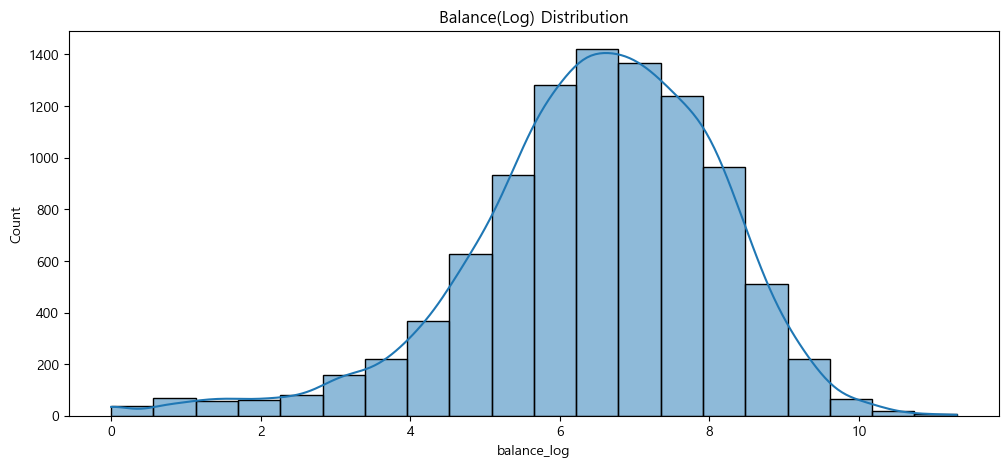

In [44]:
df['balance_log'] = np.log(df['balance'])

plt.figure(figsize=(12, 5))
sns.histplot(df['balance_log'], kde=True, bins=20)
plt.title("Balance(Log) Distribution")
plt.show()

In [ ]:
# balance 부호에 따른 이진분류 칼럼 생성
df['is_balance_minus'] = df['balance'].apply(lambda x: 'minus' if x < 0 else 'plus')

# balance_plus: 양수는 그대로, 음수는 0
df['balance_plus'] = df['balance'].apply(lambda x: x if x > 0 else 0)

# balance_minus: 음수는 절대값으로, 양수는 0
df['balance_minus'] = df['balance'].apply(lambda x: abs(x) if x < 0 else 0)

# log 변환 칼럼 추가 생성
df['balance_plus_log'] = np.log1p(df['balance_plus'])
df['balance_minus_log'] = np.log1p(df['balance_minus'])
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day  ... poutcome  deposit  age_group       date  pdays_binary  \
0    5  ...  unknown      yes      55-64 1900-05-05            -1   
1    5  ...  unknown      yes      55-64 1900-05-05            -1   
2    5  ...  unknown      yes      35-44 1900-05-05            -1   
3    5  ...  unknown      yes      55-64 1900-05-05            -1   
4    5  ...  unknown      yes      45-54 1900-05-05            -1   

       pdays_group log_balance is_balance_minus balance_plus balance_minus  
0  Never Contacted   

### **전처리 결과 종합**
- job : unknown -> other 이름 변경 (70개 행)
- education : unknown 값 age_group 생성 후 age_group 별 최빈값으로 대체
- contact : 전처리 안함
- poutcome : 전처리 안함
- pdays : 6개 구간화(grouping), pdays_binary 칼럼 생성
- balance : balance 칼럼을 is_balance_minus, balance_plus, balance_minus 3개 칼럼으로 분리 후 plus, minus 에 log 변환

> 모델 학습 전 pdays, balance, log_balance, balance_plus, balance_minus, day, month 칼럼 삭제 후 학습

In [32]:
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day  ... poutcome  deposit  age_group       date  pdays_binary  \
0    5  ...  unknown      yes      55-64 1900-05-05            -1   
1    5  ...  unknown      yes      55-64 1900-05-05            -1   
2    5  ...  unknown      yes      35-44 1900-05-05            -1   
3    5  ...  unknown      yes      55-64 1900-05-05            -1   
4    5  ...  unknown      yes      45-54 1900-05-05            -1   

       pdays_group log_balance is_balance_minus balance_plus balance_minus  
0  Never Contacted   

## EDA & 시각화

### object cols 별 deposit 비율

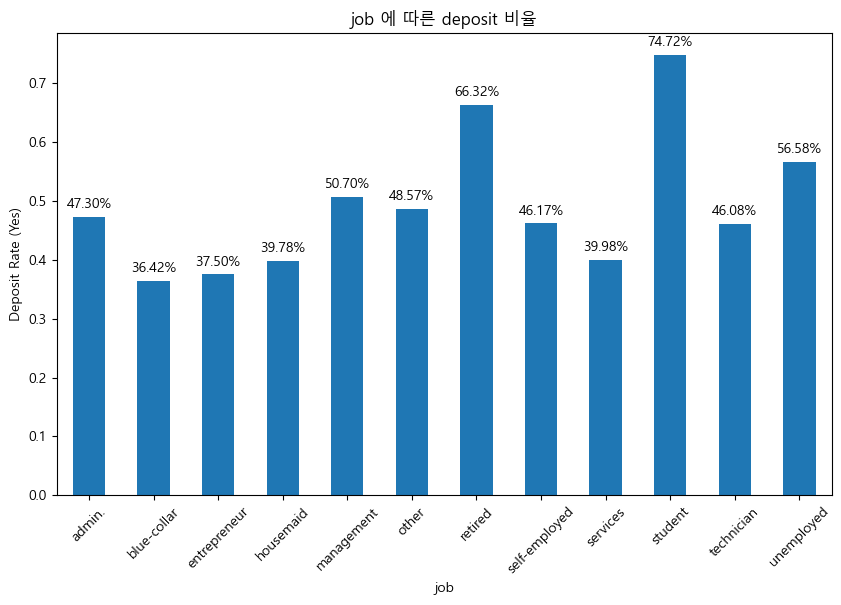

[job] 그룹별 deposit 가입률:
  - admin.: 47.30%
  - blue-collar: 36.42%
  - entrepreneur: 37.50%
  - housemaid: 39.78%
  - management: 50.70%
  - other: 48.57%
  - retired: 66.32%
  - self-employed: 46.17%
  - services: 39.98%
  - student: 74.72%
  - technician: 46.08%
  - unemployed: 56.58%


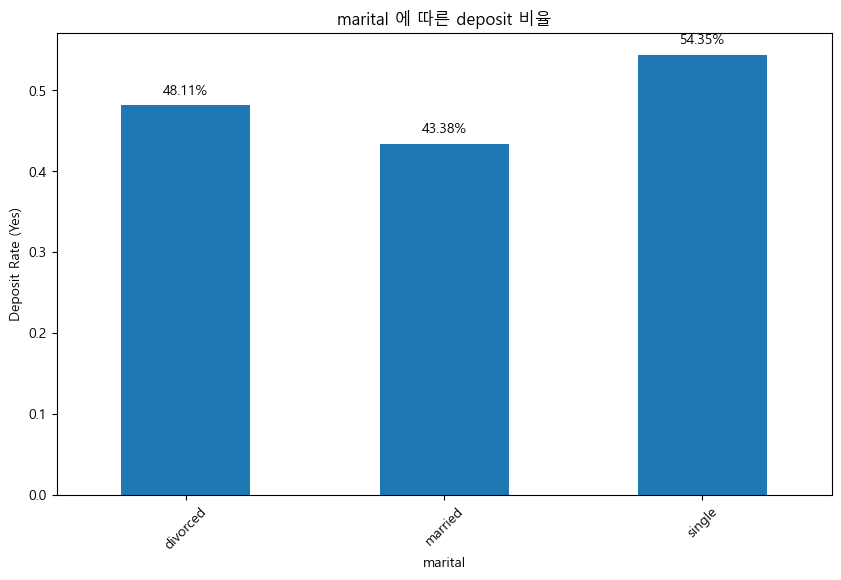

[marital] 그룹별 deposit 가입률:
  - divorced: 48.11%
  - married: 43.38%
  - single: 54.35%


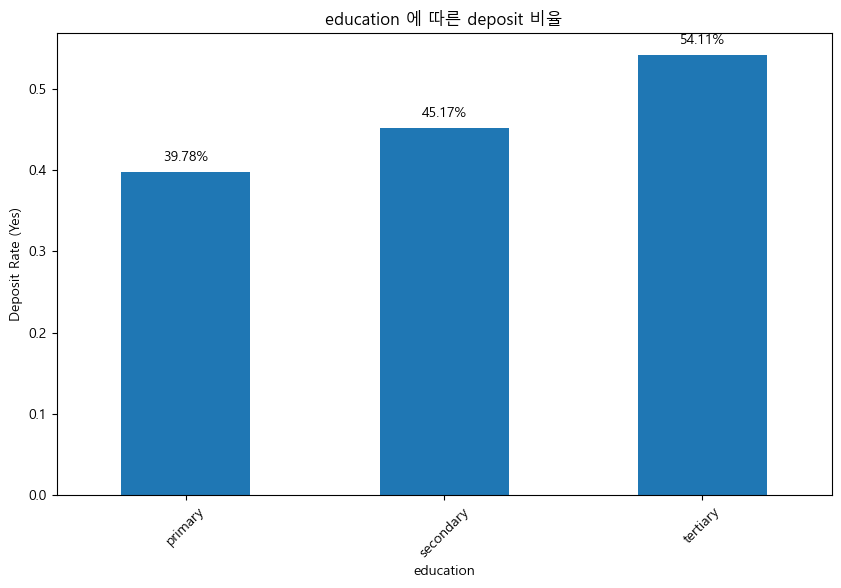

[education] 그룹별 deposit 가입률:
  - primary: 39.78%
  - secondary: 45.17%
  - tertiary: 54.11%


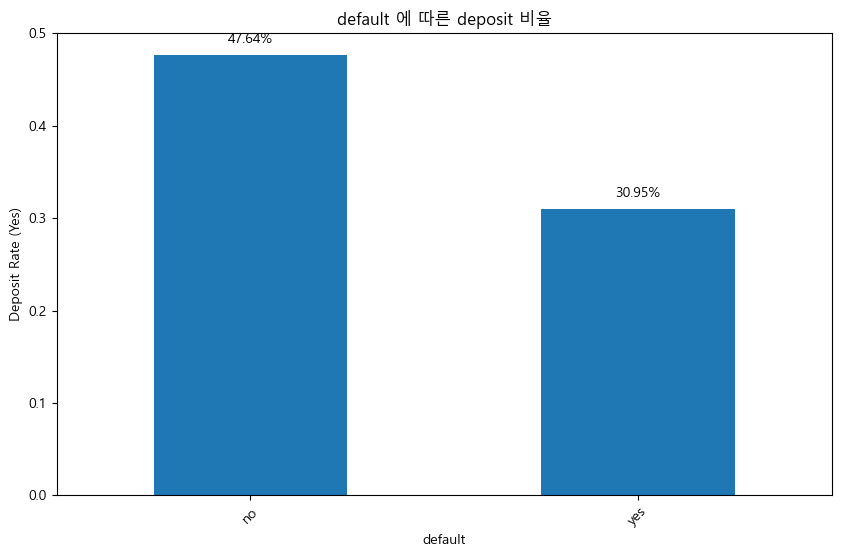

[default] 그룹별 deposit 가입률:
  - no: 47.64%
  - yes: 30.95%


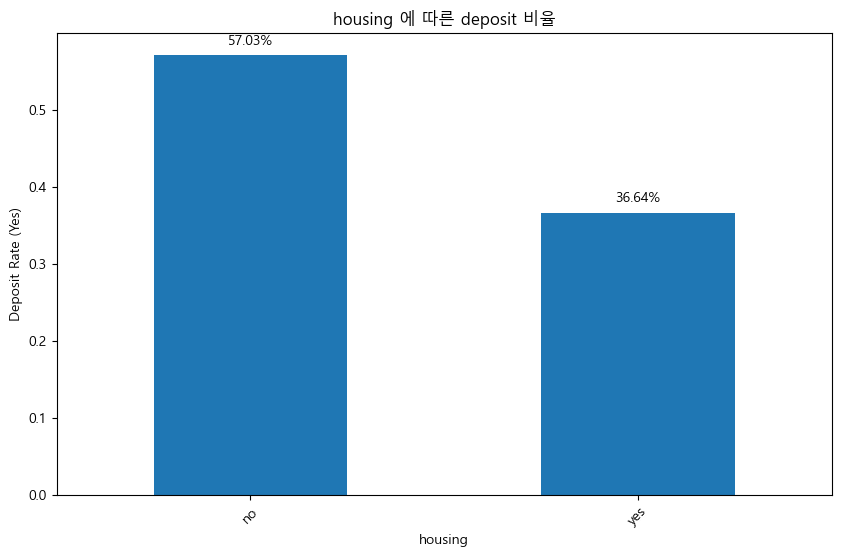

[housing] 그룹별 deposit 가입률:
  - no: 57.03%
  - yes: 36.64%


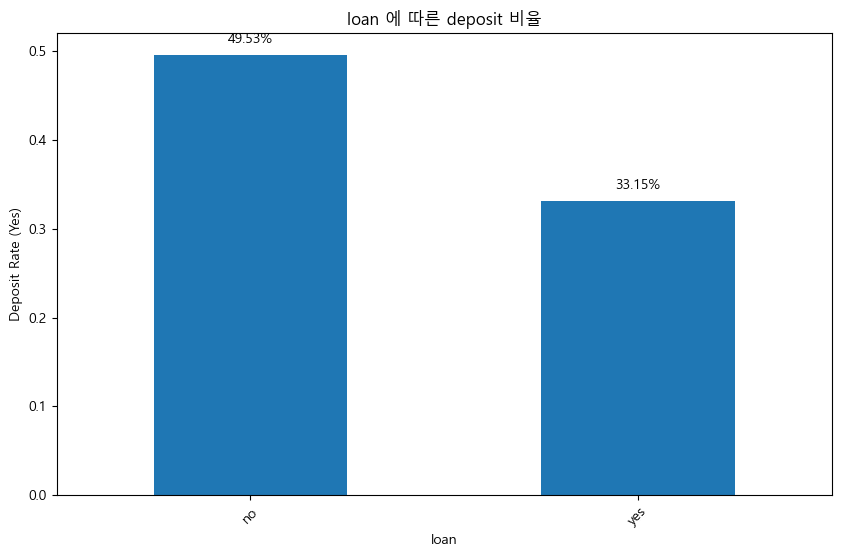

[loan] 그룹별 deposit 가입률:
  - no: 49.53%
  - yes: 33.15%


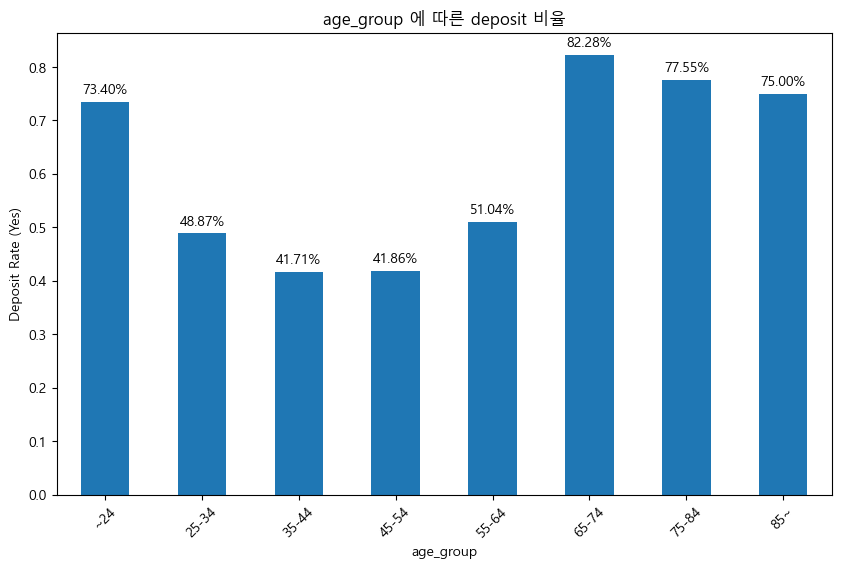

[age_group] 그룹별 deposit 가입률:
  - ~24: 73.40%
  - 25-34: 48.87%
  - 35-44: 41.71%
  - 45-54: 41.86%
  - 55-64: 51.04%
  - 65-74: 82.28%
  - 75-84: 77.55%
  - 85~: 75.00%


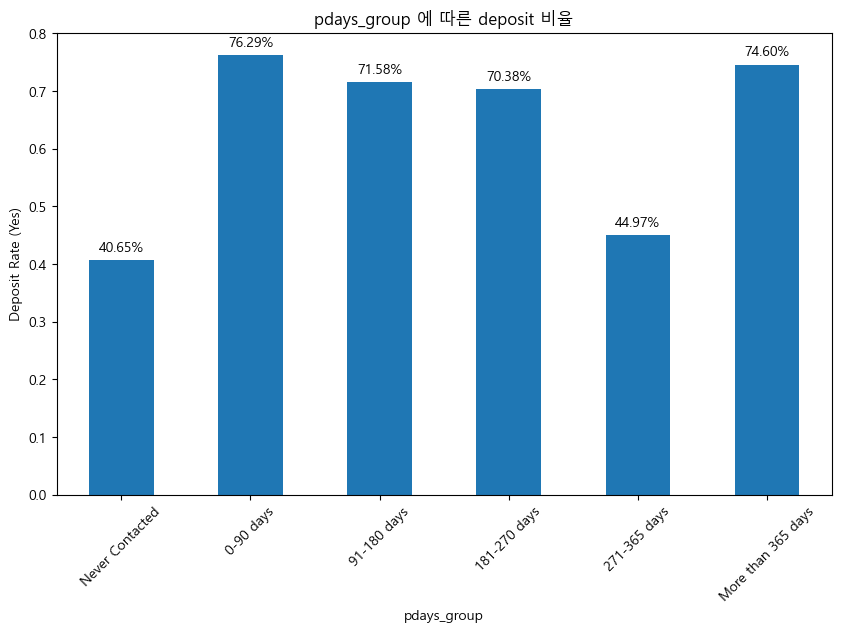

[pdays_group] 그룹별 deposit 가입률:
  - Never Contacted: 40.65%
  - 0-90 days: 76.29%
  - 91-180 days: 71.58%
  - 181-270 days: 70.38%
  - 271-365 days: 44.97%
  - More than 365 days: 74.60%


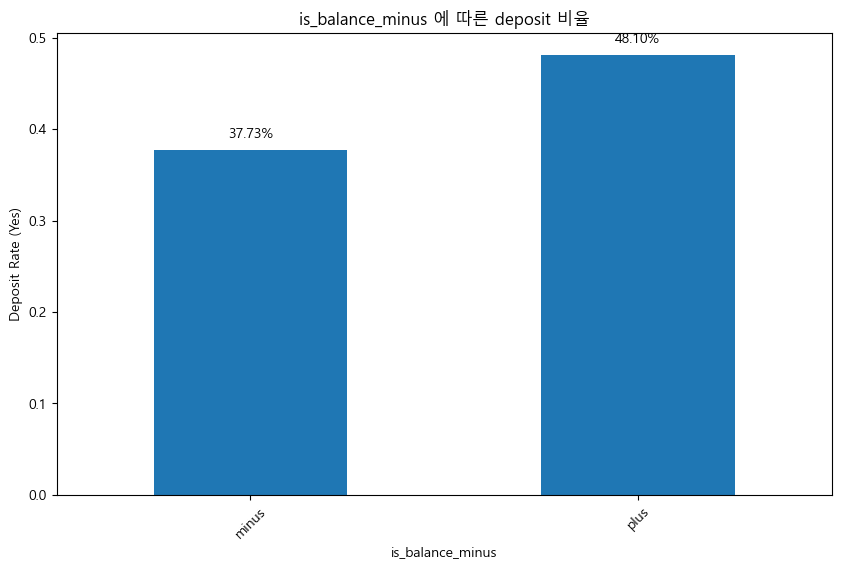

[is_balance_minus] 그룹별 deposit 가입률:
  - minus: 37.73%
  - plus: 48.10%


In [33]:
cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'age_group', 'pdays_group', 'is_balance_minus']

for col in cols:
    deposit_rate = df.groupby(col)['deposit'].value_counts(normalize=True).unstack()['yes']
    plt.figure(figsize=(10, 6))
    deposit_rate.plot(kind='bar')
    plt.title(f'{col} 에 따른 deposit 비율')
    for i, v in enumerate(deposit_rate):
        plt.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom')
    plt.ylabel('Deposit Rate (Yes)')
    plt.xticks(rotation=45)
    plt.show()

    # 시각화 결과 텍스트로 정리
    print(f"[{col}] 그룹별 deposit 가입률:")
    for group, rate in deposit_rate.items():
        print(f"  - {group}: {rate:.2%}")

> pdays_group 4 에서만 deposit ratio가 낮은 이유 : 은행 캠페인이 1년단위 정기예금으로, deposit이 만기해지되는 구간으로 추정

### date * deposit

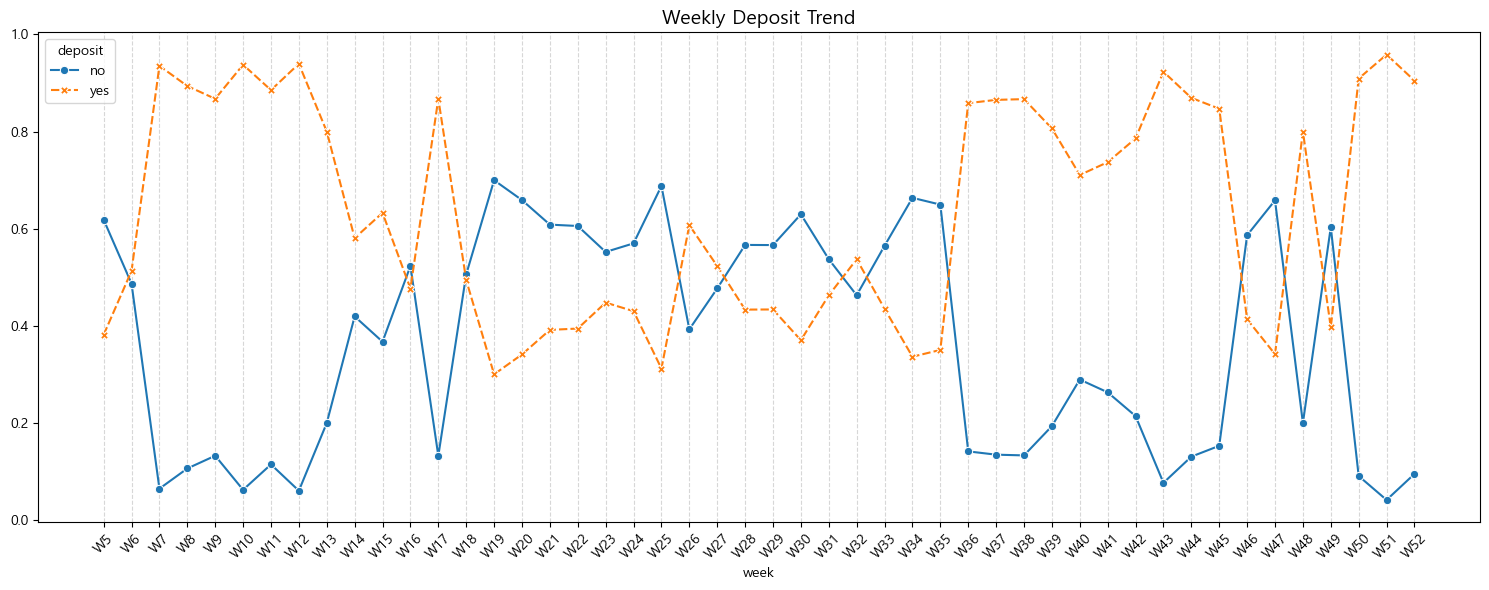

In [34]:
# 주단위 deposit 트렌드 시각화
df['week'] = df['date'].dt.isocalendar().week
weekly_trend = df.groupby('week')['deposit'].value_counts(normalize=True).unstack()

plt.figure(figsize=(15, 6))
sns.lineplot(data=weekly_trend, markers=True)

weeks = weekly_trend.index
plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)

plt.title("Weekly Deposit Trend", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

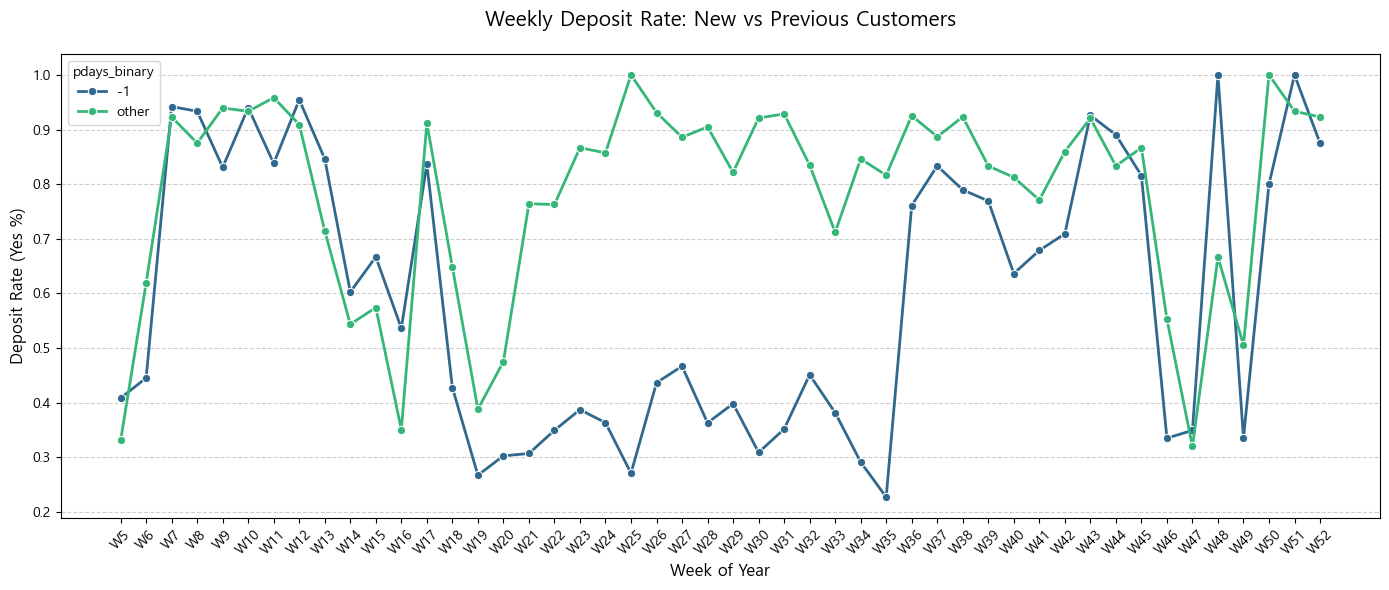

In [35]:
weekly_customer_trend = df.groupby(['week', 'pdays_binary'])['deposit'].value_counts(normalize=True).unstack()

df['week'] = df['date'].dt.isocalendar().week

# 3. 주차별 & 고객유형별 deposit='yes' 비율 계산
# normalize=True를 사용해 각 그룹 내에서의 비율을 구합니다.
weekly_res = df.groupby(['week', 'pdays_binary'])['deposit'].value_counts(normalize=True).unstack()

# 'yes' 컬럼만 추출 (가입 성공률)
trend_data = weekly_res['yes'].reset_index()

# 4. 시각화
plt.figure(figsize=(14, 6))

# 신규/기존 고객별로 선 그래프 그리기
sns.lineplot(data=trend_data, x='week', y='yes', hue='pdays_binary', 
             marker='o', linewidth=2, palette='viridis')

# 그래프 스타일링
plt.title("Weekly Deposit Rate: New vs Previous Customers", fontsize=15, pad=20)
plt.xlabel("Week of Year", fontsize=12)
plt.ylabel("Deposit Rate (Yes %)", fontsize=12)
plt.legend(title='pdays_binary', frameon=True)

# x축 눈금 최적화 (데이터가 있는 주차만 표시)
weeks = sorted(trend_data['week'].unique())
plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### date * pdays * deposit

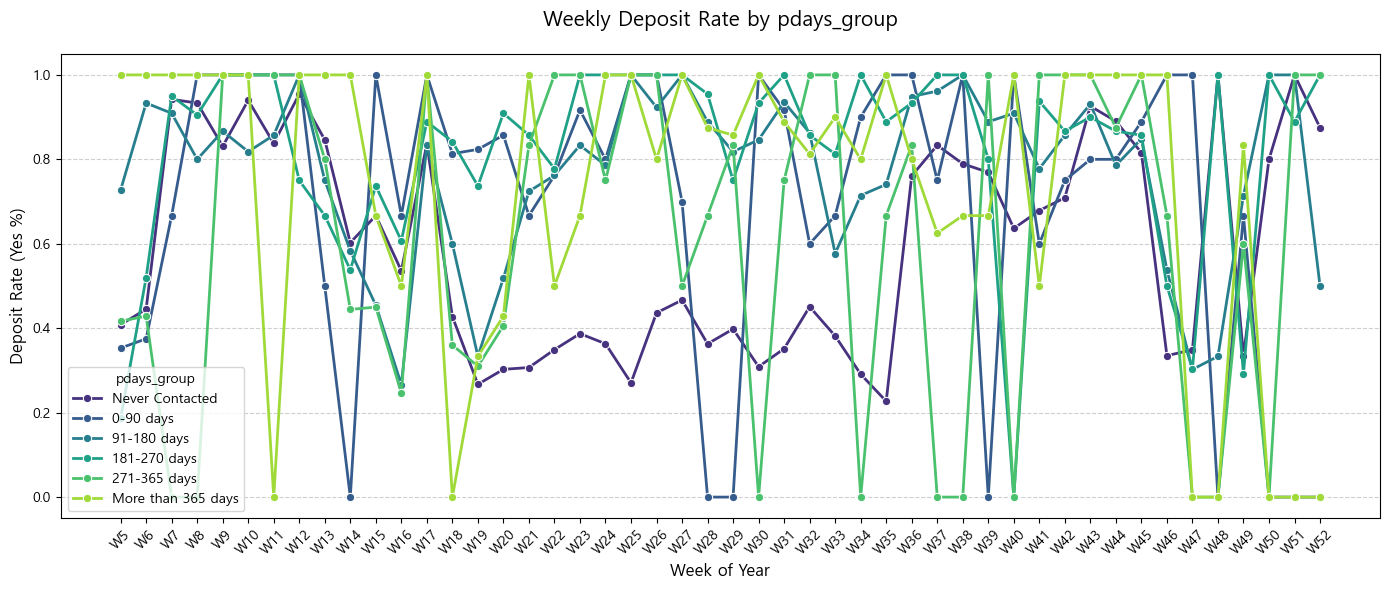

In [36]:
# pdays_group별 deposit 트렌드 시각화
weekly_res = df.groupby(['week', 'pdays_group'])['deposit'].value_counts(normalize=True).unstack()
trend_data = weekly_res['yes'].reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_data, x='week', y='yes', hue='pdays_group', 
             marker='o', linewidth=2, palette='viridis')
plt.title("Weekly Deposit Rate by pdays_group", fontsize=15, pad=20)
plt.xlabel("Week of Year", fontsize=12)
plt.ylabel("Deposit Rate (Yes %)", fontsize=12)
plt.legend(title='pdays_group', frameon=True)
weeks = sorted(trend_data['week'].unique())
plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
# 1. 시각화에 사용된 trend_data를 피벗 테이블로 변환 (행: 주차, 열: 그룹)
trend_table = trend_data.pivot(index='week', columns='pdays_group', values='yes')

# 2. 가독성을 위해 소수점 둘째자리까지 퍼센트(%)로 변환 (옵션)
trend_table_pct = (trend_table * 100).round(2)

# 3. 전체 출력 (주차가 많으므로 상위/하위 일부만 보거나 전체 출력 설정)
print("주차별 pdays_group 가입률 (단위: %)")
print(trend_table_pct)

# # 4. 특정 주차만 뽑아서 요약하고 싶다면
# print("\n가입률이 가장 높은 TOP 5 주차 (그룹별)")
# for col in trend_table_pct.columns:
#     top_week = trend_table_pct[col].idxmax()
#     top_val = trend_table_pct[col].max()
#     print(f"[{col}] 그룹: W{top_week}에 {top_val}%로 최고치 기록")

주차별 pdays_group 가입률 (단위: %)
pdays_group  Never Contacted  0-90 days  91-180 days  181-270 days  \
week                                                                 
5                      40.83      35.29        72.73         18.67   
6                      44.51      37.50        93.33         52.00   
7                      94.20      66.67        90.91         95.00   
8                      93.33     100.00        80.00         90.48   
9                      83.08     100.00        86.67        100.00   
10                     94.00     100.00        81.82        100.00   
11                     83.78     100.00        85.71        100.00   
12                     95.45     100.00       100.00         75.00   
13                     84.62      50.00        75.00         66.67   
14                     60.26       0.00        58.33         53.85   
15                     66.67     100.00        45.45         73.68   
16                     53.60      66.67        26.67         6

### duration * deposit

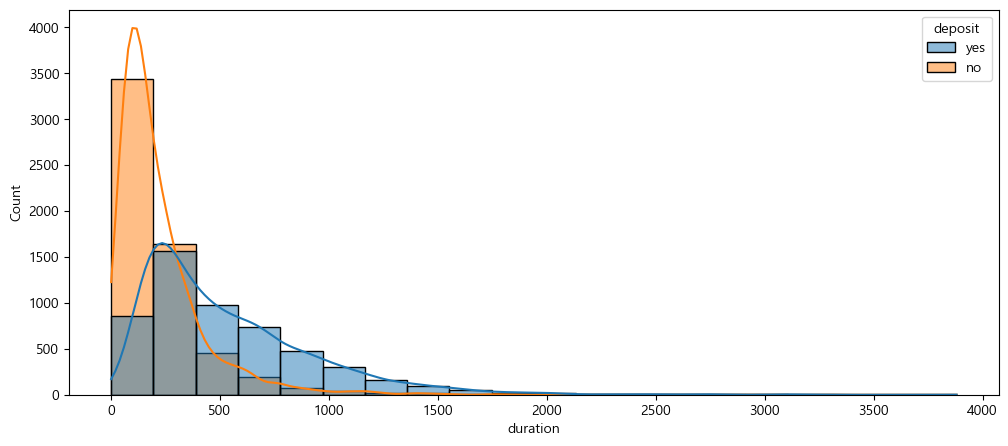

In [38]:
# deposit yes/no 별 duration 분포 시각화
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='duration', hue='deposit', kde=True, bins=20)
plt.show()

> duration 값이 클수록 deposit yes의 비율이 높게 나타남

### age * job * deposit

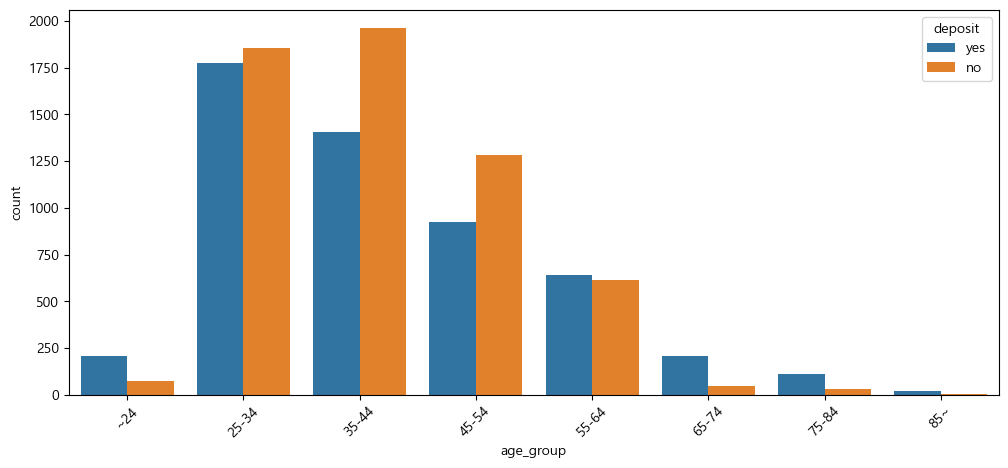

In [39]:
# age_group, job 별 deposit 비율 시각화
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='age_group', hue='deposit')
plt.xticks(rotation=45)
plt.show()

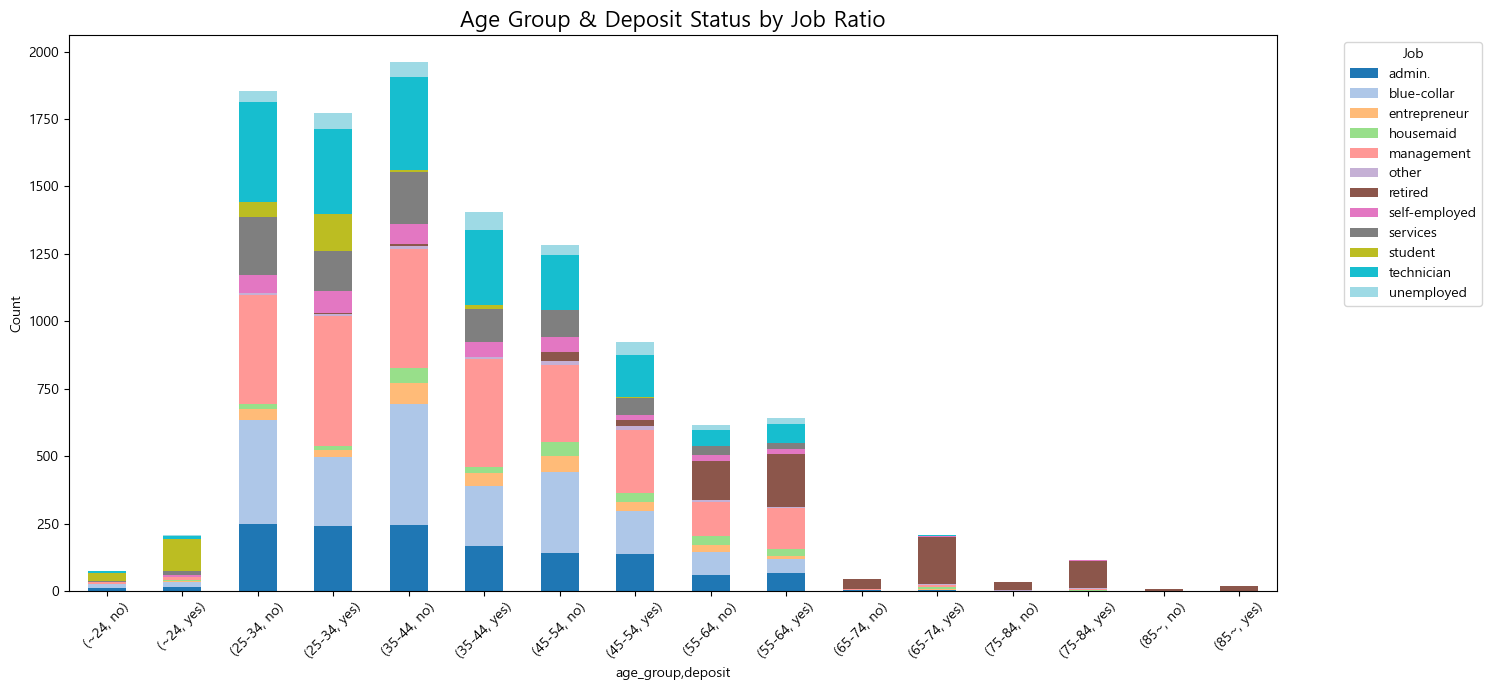

In [40]:
# 연령대와 예금 여부별로 직업군을 집계
stacked_data = df.groupby(['age_group', 'deposit', 'job']).size().unstack(fill_value=0)

# 시각화
stacked_data.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab20')

plt.title("Age Group & Deposit Status by Job Ratio", fontsize=16)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Job', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

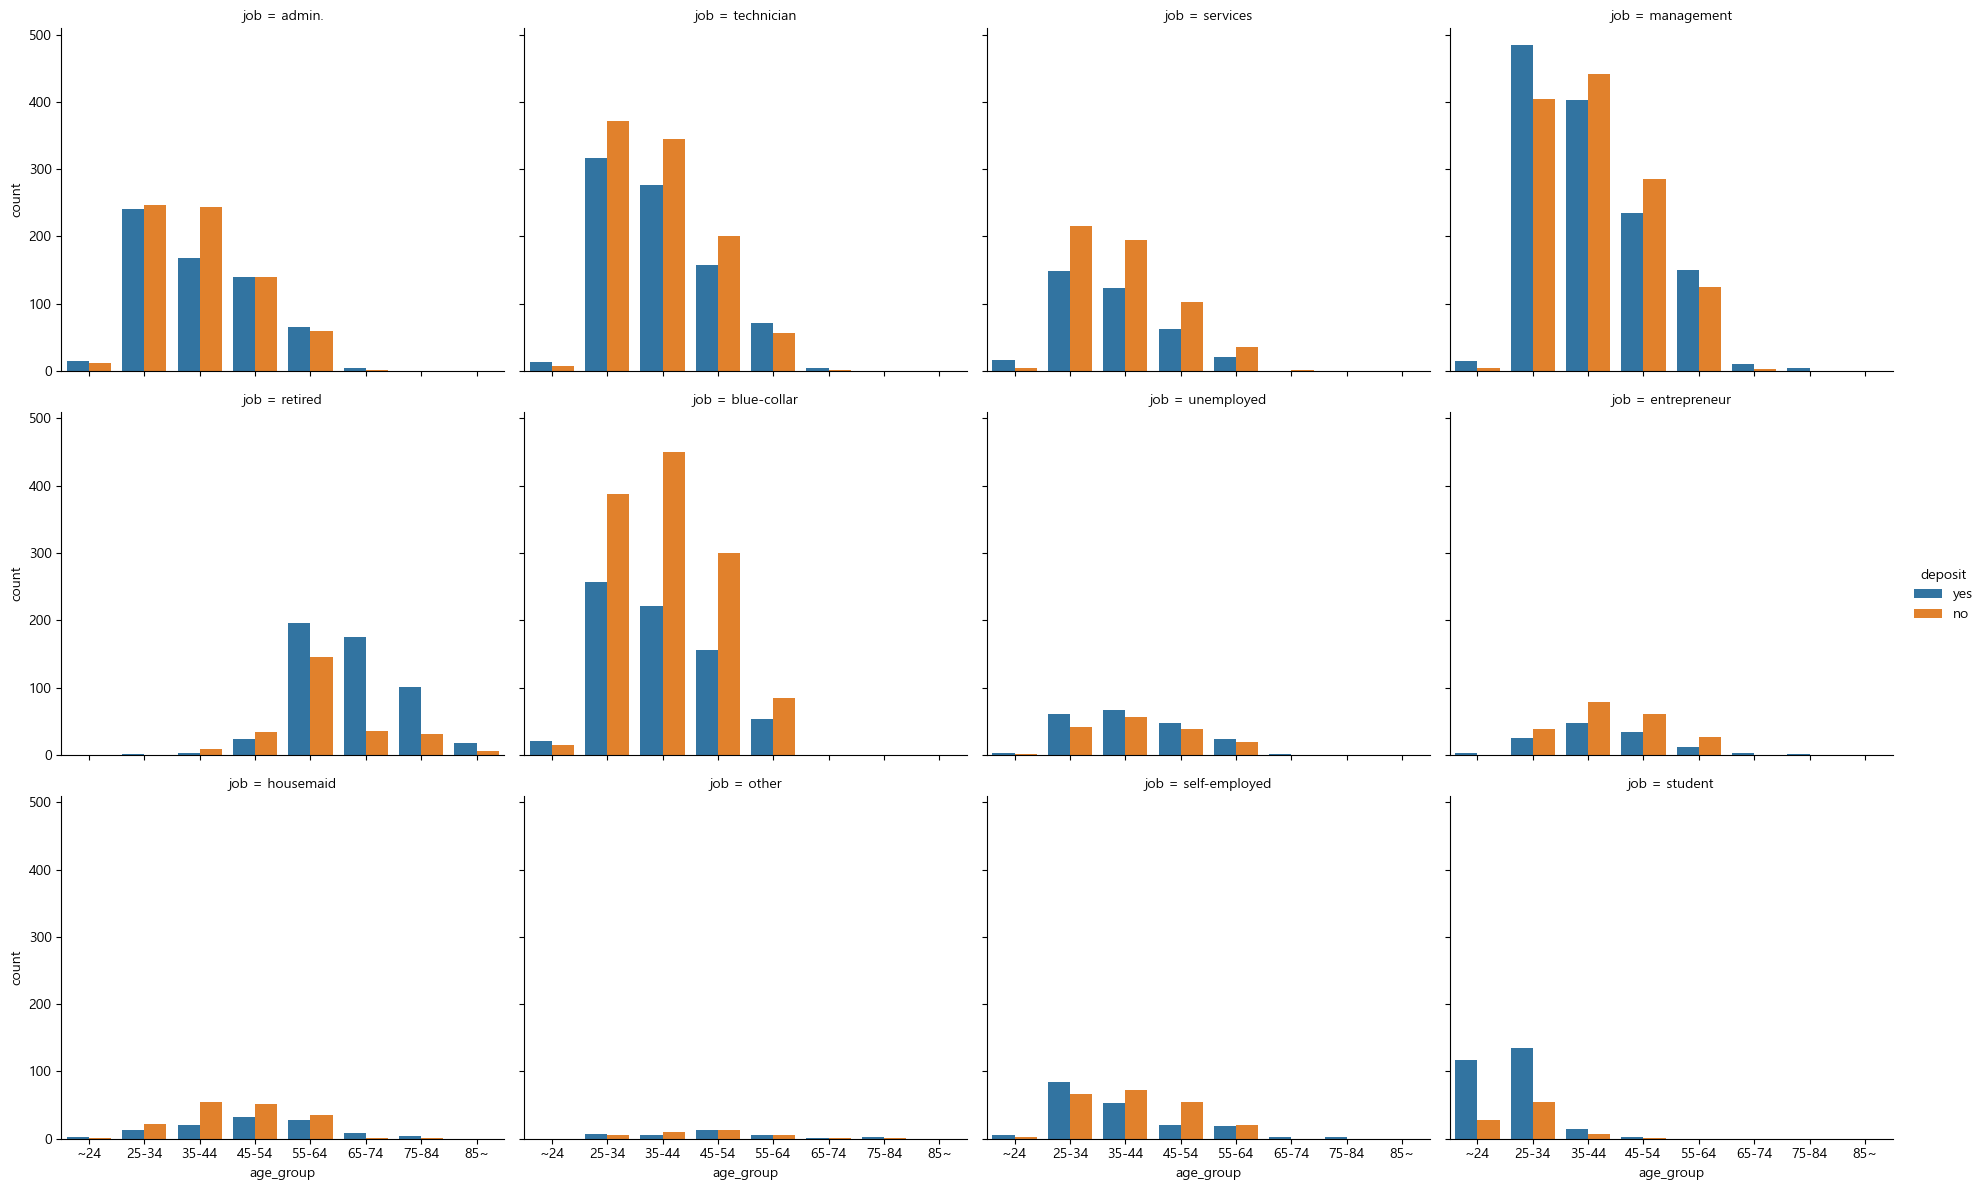

In [41]:
# 직업별로 서브플롯을 생성하여 연령대별 가입 여부 확인
sns.catplot(
    data=df, 
    x='age_group', 
    hue='deposit', 
    col='job', 
    kind='count', 
    col_wrap=4, # 한 줄에 4개씩 배치
    height=4, 
    aspect=1.2,
)

### balance * age * deposit

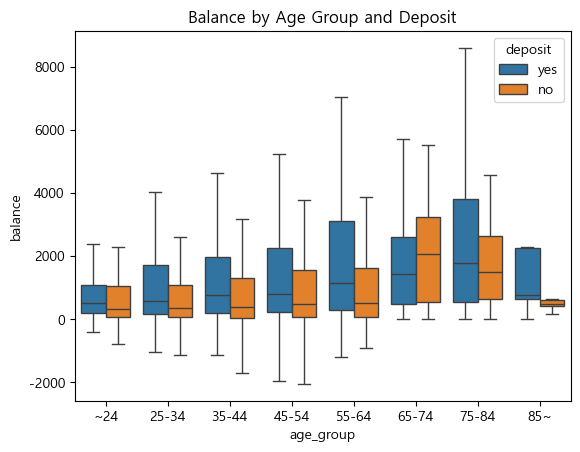

In [42]:
# balance 칼럼의 age_group과 deposit에 따른 분포 박스플롯
sns.boxplot(data=df, x='age_group', y='balance', hue='deposit', showfliers=False)
plt.title("Balance by Age Group and Deposit")
plt.show()

**시각화 해석**
- 발견: 20대 이탈률이 40대 대비 2.3배 높음
- 가설: 초기 온보딩 경험이 장기 잔존에 영향을 줄 수 있음
- 다음 확인: 가입 후 7일 이내 행동 패턴과 교차 분석 필요

## 모델링

In [38]:
# 모델링 코드

**모델 선택 근거**
- 목표: 이진 분류 (이탈 여부)
- 선택: Random Forest
- 이유: 피처 중요도 해석이 필요하고, 결측치 처리 후 데이터가 충분함 (n=8,000)
- 제외: Logistic Regression — 비선형 관계가 EDA에서 확인됨 (4.3 참조)

## 결론 / 회고

**결론**
- 핵심 발견 3가지 (수치 포함)
- 분석의 한계 (데이터 기간, 샘플 편향 등)
- 다음에 해볼 것